**Import Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [ ]:
df=pd.read_excel("/content/Delinquency_prediction_dataset.xlsx")

In [ ]:
df.shape

(500, 19)

In [ ]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,39
Credit_Score,2
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,29
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.000000,500.000000
mean,46.266000,108379.893709,577.716867,0.491446,2.968000,0.160000,48654.428875,0.298862,9.740000
std,16.187629,53662.723741,168.881211,0.197103,1.946935,0.366973,29395.537273,0.094521,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.100000,0.000000
25%,33.000000,62295.000000,418.250000,0.356486,1.000000,0.000000,23716.500000,0.233639,5.000000
50%,46.500000,107658.000000,586.000000,0.485636,3.000000,0.000000,45776.000000,0.301634,10.000000
75%,59.250000,155734.000000,727.250000,0.634440,5.000000,0.000000,75546.500000,0.362737,15.000000
max,74.000000,199943.000000,847.000000,1.025843,6.000000,1.000000,99620.000000,0.552956,19.000000


In [ ]:
print(df["Income"].median())
print(df["Loan_Balance"].median())

107658.0
45776.0


Handling Missing values


In [ ]:
df["Income"].fillna(df["Income"].median(), inplace=True)
df["Loan_Balance"].fillna(df["Loan_Balance"].median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,2
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
df["Credit_Score"].fillna(df["Credit_Score"].median(), inplace=True)

In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Credit_Score,0
Credit_Utilization,0
Missed_Payments,0
Delinquent_Account,0
Loan_Balance,0
Debt_to_Income_Ratio,0
Employment_Status,0


In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                500 non-null    float64
 3   Credit_Score          500 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          500 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
df.select_dtypes(include="object").columns

Index(['Customer_ID', 'Employment_Status', 'Credit_Card_Type', 'Location',
       'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [ ]:
df["Delinquent_Account"].value_counts()

,count
Delinquent_Account,
0,420
1,80


In [ ]:
df.drop("Customer_ID", axis=1, inplace=True)

In [ ]:
for col in ['Employment_Status','Credit_Card_Type','Location',
            'Month_1','Month_2','Month_3',
            'Month_4','Month_5','Month_6']:
    print(f"\n{col}")
    print(df[col].unique())


Employment_Status
['EMP' 'Self-employed' 'Unemployed' 'employed' 'Employed' 'retired']

Credit_Card_Type
['Student' 'Standard' 'Platinum' 'Gold' 'Business']

Location
['Los Angeles' 'Phoenix' 'Chicago' 'New York' 'Houston']

Month_1
['Late' 'Missed' 'On-time']

Month_2
['Late' 'Missed' 'On-time']

Month_3
['Missed' 'Late' 'On-time']

Month_4
['Late' 'Missed' 'On-time']

Month_5
['Missed' 'On-time' 'Late']

Month_6
['Late' 'On-time' 'Missed']


In [ ]:
df["Employment_Status"] = df["Employment_Status"].replace({
    "EMP": "Employed",
    "employed": "Employed",
    "retired": "Retired"
})

In [ ]:
print(df["Employment_Status"].unique())

['Employed' 'Self-employed' 'Unemployed' 'Retired']


In [ ]:
payment_mapping = {
    "On-time": 0,
    "Late": 1,
    "Missed": 2
}

for col in ["Month_1", "Month_2", "Month_3",
            "Month_4", "Month_5", "Month_6"]:
    df[col] = df[col].map(payment_mapping)

One hot coding using dummy variable


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "Employment_Status",
        "Credit_Card_Type",
        "Location"
    ],
    drop_first=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              500 non-null    int64  
 1   Income                           500 non-null    float64
 2   Credit_Score                     500 non-null    float64
 3   Credit_Utilization               500 non-null    float64
 4   Missed_Payments                  500 non-null    int64  
 5   Delinquent_Account               500 non-null    int64  
 6   Loan_Balance                     500 non-null    float64
 7   Debt_to_Income_Ratio             500 non-null    float64
 8   Account_Tenure                   500 non-null    int64  
 9   Month_1                          500 non-null    int64  
 10  Month_2                          500 non-null    int64  
 11  Month_3                          500 non-null    int64  
 12  Month_4               

Target variable

In [ ]:
X = df.drop("Delinquent_Account", axis=1)
y = df["Delinquent_Account"]

Training and testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
df.to_csv("cleaned_credit_dataset.csv", index=False)

In [ ]:
print(X.shape)
print(y.shape)

(500, 25)
(500,)


Scaling columns


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.46

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.46      0.59        84
           1       0.13      0.44      0.21        16

    accuracy                           0.46       100
   macro avg       0.47      0.45      0.40       100
weighted avg       0.70      0.46      0.53       100



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

cm

array([[39, 45],
       [ 9,  7]])

Data Visual Analysis

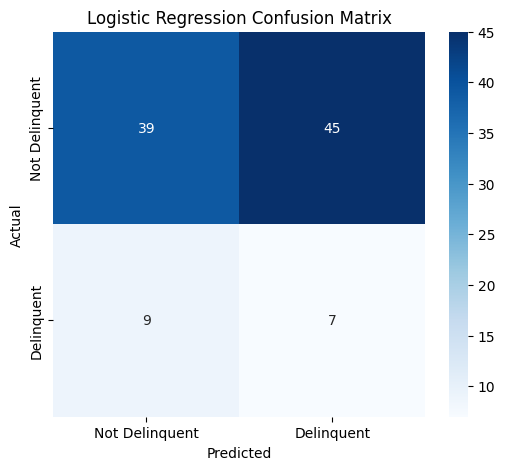

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))y

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Delinquent','Delinquent'],
    yticklabels=['Not Delinquent','Delinquent']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

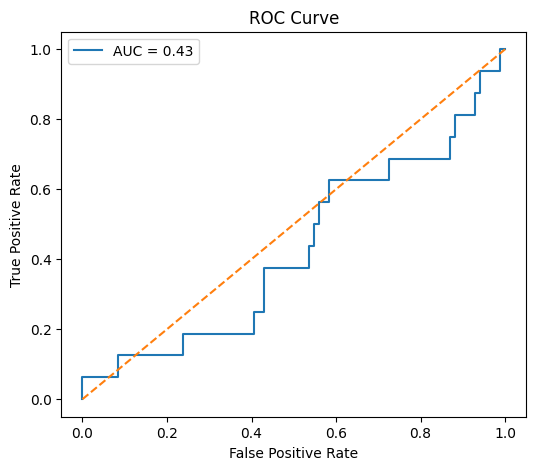

In [ ]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

**Decision tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5, class_weight="balanced"
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.77      0.27      0.40        84
           1       0.13      0.56      0.21        16

    accuracy                           0.32       100
   macro avg       0.45      0.42      0.31       100
weighted avg       0.66      0.32      0.37       100



In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

**Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91        84
           1       0.00      0.00      0.00        16

    accuracy                           0.84       100
   macro avg       0.42      0.50      0.46       100
weighted avg       0.71      0.84      0.77       100



In [ ]:
import joblib

joblib.dump(rf, "random_forest.pkl")

['random_forest.pkl']

Hugging face API Key

In [ ]:
!pip install -q langgraph langchain langchain-core langchain-community
!pip install -q langchain-huggingface huggingface_hub transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


KeyboardInterrupt: 

In [ ]:
import os

os.environ["HF_TOKEN"] = "YOUR TOKEN KEY"

In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    api_key=os.environ["HF_TOKEN"]
)

response = client.chat.completions.create(
    model="Qwen/Qwen2.5-7B-Instruct",
    messages=[
        {
            "role": "user",
            "content": "Reply with only: Hugging Face Connected"
        }
    ],
    max_tokens=20
)

print(response.choices[0].message.content)

Hugging Face Connected


In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, END

In [ ]:
class AgentState(TypedDict):
    customer: dict
    prediction: int
    probability: float
    analysis: str
    recommendation: str
    email: str

In [ ]:
import numpy as np

def prediction_node(state):

    customer = state["customer"]

    prediction = rf.predict(customer)[0]

    probability = rf.predict_proba(customer)[0][1]

    state["prediction"] = int(prediction)

    state["probability"] = float(probability)

    return state

In [ ]:
customer = X_test.iloc[[5]]

In [ ]:
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
print(X_test.shape)

(100, 25)


In [ ]:
from typing import TypedDict

class AgentState(TypedDict):
    customer: dict
    prediction: int
    probability: float
    analysis: str
    recommendation: str
    email: str

In [ ]:
def prediction_node(state):

    customer = state["customer"]

    prediction = rf.predict(customer)[0]

    probability = rf.predict_proba(customer)[0][1]

    state["prediction"] = int(prediction)
    state["probability"] = float(probability)

    return state

In [ ]:
customer = X_test.iloc[[5]]

state = {
    "customer": customer,
    "prediction": 0,
    "probability": 0.0,
    "analysis": "",
    "recommendation": "",
    "email": ""
}

result = prediction_node(state)

print(result)

{'customer':      Age   Income  Credit_Score  Credit_Utilization  Missed_Payments  \
320   18  53513.0         391.0            0.835958                2   

     Loan_Balance  Debt_to_Income_Ratio  Account_Tenure  Month_1  Month_2  \
320       82382.0              0.343389               0        2        0   

     ...  Employment_Status_Self-employed  Employment_Status_Unemployed  \
320  ...                            False                          True   

     Credit_Card_Type_Gold  Credit_Card_Type_Platinum  \
320                  False                      False   

     Credit_Card_Type_Standard  Credit_Card_Type_Student  Location_Houston  \
320                       True                     False             False   

     Location_Los Angeles  Location_New York  Location_Phoenix  
320                 False              False              True  

[1 rows x 25 columns], 'prediction': 0, 'probability': 0.13, 'analysis': '', 'recommendation': '', 'email': ''}


In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient(
    api_key=os.environ["HF_TOKEN"]
)

In [ ]:
def analysis_node(state):

    prediction = state["prediction"]
    probability = state["probability"]

    prompt = f"""
    You are an AI collections analyst.

    The machine learning model predicted:

    Prediction: {prediction}

    Probability of delinquency: {probability:.2%}

    Explain in simple business language:

    1. What this prediction means.
    2. Why this customer received this prediction.
    3. Keep it under 100 words.
    """

    response = client.chat.completions.create(
        model="Qwen/Qwen2.5-7B-Instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=150
    )

    state["analysis"] = response.choices[0].message.content

    return state

In [ ]:
state = analysis_node(state)

print(state["analysis"])

1. This prediction means the model believes the customer is not likely to become delinquent.
2. The customer received this prediction because their risk factors are below the threshold for delinquency, based on historical data and current financial metrics.


In [ ]:
class AgentState(TypedDict):
    customer: dict
    prediction: int
    probability: float
    plan: str
    analysis: str
    recommendation: str
    email: str

In [ ]:
def planner_node(state):

    prediction = state["prediction"]
    probability = state["probability"]

    prompt = f"""
You are an AI Collections Manager.

The ML model predicted:

Prediction: {prediction}
Probability: {probability:.2%}

Choose ONLY ONE strategy.

Options:

1. Monitor
2. Friendly Reminder
3. Payment Plan
4. Escalate

Return ONLY the strategy name.
"""

    response = client.chat.completions.create(
        model="Qwen/Qwen2.5-7B-Instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=20
    )

    state["plan"] = response.choices[0].message.content.strip()

    return state

In [ ]:
state = planner_node(state)

print(state["plan"])

Monitor


In [ ]:
def recommendation_node(state):

    plan = state["plan"]

    prompt = f"""
You are an AI Collections Advisor.

The selected collection strategy is:

{plan}

Write a professional recommendation for the collections team in less than 80 words.
"""

    response = client.chat.completions.create(
        model="Qwen/Qwen2.5-7B-Instruct",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        max_tokens=120
    )

    state["recommendation"] = response.choices[0].message.content

    return state

In [ ]:
state = recommendation_node(state)

print(state["recommendation"])

Recommend a proactive monitoring strategy to identify and address potential delinquencies early. This will enhance customer relationships and improve cash flow efficiency. Regularly review and update monitoring criteria based on performance data.


In [ ]:
def email_node(state):

    plan = state["plan"]

    prompt = f"""
Write a professional and polite email to a customer.

Collection Strategy:
{plan}

Keep the email under 120 words.
"""

    response = client.chat.completions.create(
        model="Qwen/Qwen2.5-7B-Instruct",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        max_tokens=180
    )

    state["email"] = response.choices[0].message.content

    return state

In [ ]:
state = email_node(state)

print(state["email"])

Subject: Monitoring Your Account for Payment

Dear [Customer's Name],

I hope this message finds you well. We are monitoring your account to ensure timely payment. If you have any questions or need assistance, please feel free to reach out.

Best regards,

[Your Full Name]  
[Your Position]  
[Your Contact Information]  
[Company Name]


In [ ]:
workflow = StateGraph(AgentState)

In [ ]:
workflow.add_node("Prediction", prediction_node)
workflow.add_node("Planner", planner_node)
workflow.add_node("Analysis", analysis_node)
workflow.add_node("Recommendation", recommendation_node)
workflow.add_node("Email", email_node)

In [ ]:
workflow.set_entry_point("Prediction")

workflow.add_edge("Prediction", "Planner")
workflow.add_edge("Planner", "Analysis")
workflow.add_edge("Analysis", "Recommendation")
workflow.add_edge("Recommendation", "Email")
workflow.add_edge("Email", END)

In [ ]:
app = workflow.compile()

In [ ]:
result = app.invoke(state)

In [ ]:
print("Prediction:", result["prediction"])

print("Probability:", result["probability"])

print("\nPlan:")
print(result["plan"])

print("\nAnalysis:")
print(result["analysis"])

print("\nRecommendation:")
print(result["recommendation"])

print("\nEmail:")
print(result["email"])

Prediction: 0
Probability: 0.13

Plan:
Monitor

Analysis:
1. This prediction means the model assesses a low risk of the customer becoming delinquent.
2. The customer likely has a good payment history and meets the criteria for low-risk borrowers, leading to a 13% probability of delinquency.

Recommendation:
Recommend a proactive monitoring strategy to identify and address potential delinquencies early. This will enhance customer relationships and improve cash flow efficiency. Regularly review and update monitoring criteria based on performance data.

Email:
Subject: Monitoring Your Account for Payment

Dear [Customer's Name],

I hope this message finds you well. We are monitoring your account to ensure timely payment. If you have any questions or need assistance, please feel free to reach out.

Best regards,

[Your Full Name]  
[Your Position]  
[Your Contact Information]  
[Company Name]


In [ ]:
print(X.columns.tolist())

['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Employment_Status_Retired', 'Employment_Status_Self-employed', 'Employment_Status_Unemployed', 'Credit_Card_Type_Gold', 'Credit_Card_Type_Platinum', 'Credit_Card_Type_Standard', 'Credit_Card_Type_Student', 'Location_Houston', 'Location_Los Angeles', 'Location_New York', 'Location_Phoenix']


In [ ]:
import pandas as pd

def preprocess_input(user_input):

    df = pd.DataFrame([user_input])

    # One-hot encode categorical columns
    df = pd.get_dummies(
        df,
        columns=[
            "Employment_Status",
            "Credit_Card_Type",
            "Location"
        ]
    )

    # Match training columns
    df = df.reindex(columns=X.columns, fill_value=0)

    # Convert only boolean columns to integers
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)

    return df

In [ ]:
customer = {
    "Age":25,
    "Income":65000,
    "Credit_Score":720,
    "Credit_Utilization":0.35,
    "Missed_Payments":1,
    "Loan_Balance":150000,
    "Debt_to_Income_Ratio":0.28,
    "Account_Tenure":5,

    "Month_1":2,
    "Month_2":2,
    "Month_3":2,
    "Month_4":2,
    "Month_5":2,
    "Month_6":2,

    "Employment_Status":"Employed",
    "Credit_Card_Type":"Gold",
    "Location":"Phoenix"
}

In [ ]:
customer_df = preprocess_input(customer)

print(customer_df)

   Age  Income  Credit_Score  Credit_Utilization  Missed_Payments  \
0   25   65000           720                0.35                1   

   Loan_Balance  Debt_to_Income_Ratio  Account_Tenure  Month_1  Month_2  ...  \
0        150000                  0.28               5        2        2  ...   

   Employment_Status_Self-employed  Employment_Status_Unemployed  \
0                                0                             0   

   Credit_Card_Type_Gold  Credit_Card_Type_Platinum  \
0                      1                          0   

   Credit_Card_Type_Standard  Credit_Card_Type_Student  Location_Houston  \
0                          0                         0                 0   

   Location_Los Angeles  Location_New York  Location_Phoenix  
0                     0                  0                 1  

[1 rows x 25 columns]


In [ ]:
prediction = rf.predict(customer_df)[0]

probability = rf.predict_proba(customer_df)[0][1]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: 0.08


In [ ]:
df = df.astype(int)

In [ ]:
import os

os.listdir()

['.config',
 'logistic_model.pkl',
 'random_forest.pkl',
 'Delinquency_prediction_dataset.xlsx',
 'cleaned_credit_dataset.csv',
 'sample_data']

Download Model-Random Forest classifier

In [ ]:

from google.colab import files

files.download("random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X.columns

Index(['Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Loan_Balance', 'Debt_to_Income_Ratio',
       'Account_Tenure', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5',
       'Month_6', 'Employment_Status_Retired',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Credit_Card_Type_Gold', 'Credit_Card_Type_Platinum',
       'Credit_Card_Type_Standard', 'Credit_Card_Type_Student',
       'Location_Houston', 'Location_Los Angeles', 'Location_New York',
       'Location_Phoenix'],
      dtype='object')

In [ ]:
print(lr.classes_)

[0 1]


In [ ]:
print(y.value_counts())

Delinquent_Account
0    420
1     80
Name: count, dtype: int64


SMOTE analysis for Imbalanced dataset

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Delinquent_Account", axis=1)
y = df["Delinquent_Account"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Delinquent_Account
0    336
1     64
Name: count, dtype: int64
Delinquent_Account
0    336
1    336
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86        84
           1       0.09      0.06      0.07        16

    accuracy                           0.75       100
   macro avg       0.46      0.47      0.46       100
weighted avg       0.71      0.75      0.73       100



In [ ]:
import numpy as np

print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([89, 11]))


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86        84
           1       0.09      0.06      0.07        16

    accuracy                           0.75       100
   macro avg       0.46      0.47      0.46       100
weighted avg       0.71      0.75      0.73       100



In [ ]:
import joblib

joblib.dump(model, "logistic_model.pkl")

['logistic_model.pkl']

In [ ]:
from google.colab import files

files.download("logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>